# Kaluza-Klein extra-dimension world

This notebook validates the new `extra_dimensions` world before handing it to a discovery agent.

**Hidden physics.** Two particles in a *visible* 2D universe, but with a single extra spatial dimension compactified on a circle of radius $R_c$. Particle 1 sits fixed at the origin with source coupling $p_1$; particle 2 has inertia $p_2$ and feels the Kaluza-Klein image-charge sum

\[
\mathbf{F}_2(r) \;=\; \frac{G\,L\,p_1}{4\pi}\,\sum_{n\in\mathbb{Z}}\frac{r}{(r^2+(nL)^2)^{3/2}}\,(-\hat{\mathbf{r}}),\qquad L = 2\pi R_c
\]

with hidden defaults $G = 1$, $R_c = 0.5$ (so $L \approx 3.14$). The sum has two limits, and these are what the agent must distinguish:

* $r \gg R_c$ — the sum becomes an integral and $F \to p_1/(2\pi r)$. This is **identical** to the standard 2D `gravity` world.
* $r \lesssim R_c$ — only the $n=0$ image survives and $F \to G L p_1 / (4\pi r^2) = R_c p_1 / (2 r^2)$. This is **3D Newtonian inverse-square** — the extra dimension "opens up".

An agent that runs experiments at typical separations ($r \approx 3$–$5$) will see clean 2D Poisson dynamics and conclude this is just gravity. The extra dimension only reveals itself with experiments at $r \lesssim 1$.

What we'll show below:

1. Plot $F(r)$ versus $r$ on log-log axes and overlay the 2D Poisson and 3D Newtonian asymptotes.
2. Confirm that "naïve" experiments at $r \sim 3$ are essentially indistinguishable from the gravity world.
3. Show the qualitative trajectory difference at small $r$ (3D-Newtonian behaviour) versus large $r$ (2D-Poisson behaviour).
4. Demonstrate how an agent can recover $G$ *and* $R_c$ by sweeping a radial-Δv measurement across a wide range of starting distances.
5. Implement a candidate `discovered_law` that uses `fit_parameters()` for $G$ and $R_c$, and verify it reproduces the executor's trajectories on the standard evaluator test cases — confirming a 10/10 answer is achievable.

In [2]:
import sys
import pathlib

_ROOT = pathlib.Path.cwd()
while _ROOT != _ROOT.parent and not (_ROOT / "ScienceAgent").is_dir():
    _ROOT = _ROOT.parent
sys.path.insert(0, str(_ROOT / "ScienceAgent"))

import numpy as np
import matplotlib.pyplot as plt

from scienceagent.worlds import get_world
from scienceagent.executor import (
    NBodyKaluzaKleinExecutor,
    NBodySimulationExecutor,
)
from scienceagent.evaluator import Evaluator

world = get_world("extra_dimensions", engine="nbody")
executor = world["executor"]
print("World mission (truncated):")
print(world["mission"][:280] + " …")
print()
print("Hidden parameters baked into NBodyKaluzaKleinExecutor:")
print(f"  G         = {NBodyKaluzaKleinExecutor.G}")
print(f"  R_compact = {NBodyKaluzaKleinExecutor.R_COMPACT}")
print(f"  L = 2π R  = {2 * np.pi * NBodyKaluzaKleinExecutor.R_COMPACT:.4f}")
print(f"  n_images  = {NBodyKaluzaKleinExecutor.N_IMAGES}")

World mission (truncated):
Two particles interact through an unknown field in a 2D universe. The field is generated by particle 1 and exerts a force on particle 2. At first glance the force law may look quite ordinary — but the underlying geometry of space in this universe might not be exactly what it appe …

Hidden parameters baked into NBodyKaluzaKleinExecutor:
  G         = 1.0
  R_compact = 0.5
  L = 2π R  = 3.1416
  n_images  = 20


## 1. Force law: dimensional crossover at $r \sim R_c$

The agent never sees the analytic $F(r)$ directly — only its effect through trajectories. We plot it here on log-log axes to fix intuition. The two dashed lines are the asymptotic limits the agent's two natural hypotheses (2D `gravity` world or 3D Newtonian) would predict; the solid curve is the true KK force law.

The crossover region sits around $r \sim L = 2\pi R_c \approx 3.1$. Below the *compactification radius* $R_c = 0.5$, the force is essentially pure 3D inverse-square; above $r \approx 5$ it's essentially pure 2D Poisson.

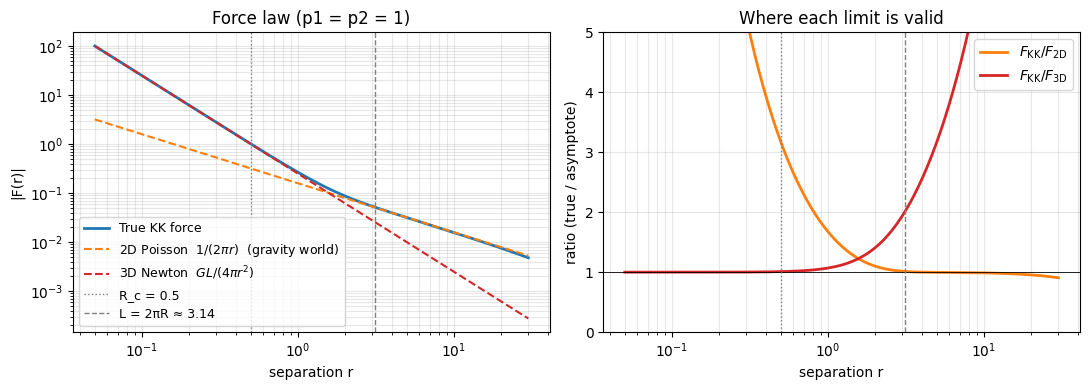

Quick numerical check at a few separations:
  r = 0.1   F = 25.0019   3D-Newton prediction = 25.0000
  r = 1.0   F = 0.2671   (between the two limits, in the crossover)
  r = 5.0   F = 0.031747   2D-Poisson prediction = 0.031831
  r = 10    F = 0.015727   2D-Poisson prediction = 0.015915


In [3]:
G = NBodyKaluzaKleinExecutor.G
R = NBodyKaluzaKleinExecutor.R_COMPACT
L = 2 * np.pi * R

r_grid = np.geomspace(0.05, 30, 400)
F_kk = NBodyKaluzaKleinExecutor.force_magnitude(r_grid)
F_2d = G / (2 * np.pi * r_grid)                 # long-range asymptote
F_3d = G * L / (4 * np.pi * r_grid**2)          # short-range asymptote

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(r_grid, F_kk, color="C0", lw=2.0, label="True KK force")
axes[0].loglog(r_grid, F_2d, "--", color="C1", lw=1.5,
               label=r"2D Poisson  $1/(2\pi r)$  (gravity world)")
axes[0].loglog(r_grid, F_3d, "--", color="C3", lw=1.5,
               label=r"3D Newton  $G L/(4\pi r^2)$")
axes[0].axvline(R,  color="grey", ls=":", lw=1.0, label=f"R_c = {R}")
axes[0].axvline(L,  color="grey", ls="--", lw=1.0, label=f"L = 2πR ≈ {L:.2f}")
axes[0].set_xlabel("separation r")
axes[0].set_ylabel("|F(r)|")
axes[0].set_title("Force law (p1 = p2 = 1)")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].grid(True, which="both", alpha=0.3)

# Same data, plotted as a ratio to each asymptote.
axes[1].semilogx(r_grid, F_kk / F_2d, color="C1", lw=2.0,
                 label=r"$F_{\rm KK}/F_{\rm 2D}$")
axes[1].semilogx(r_grid, F_kk / F_3d, color="C3", lw=2.0,
                 label=r"$F_{\rm KK}/F_{\rm 3D}$")
axes[1].axhline(1.0, color="k", lw=0.6)
axes[1].axvline(R,  color="grey", ls=":", lw=1.0)
axes[1].axvline(L,  color="grey", ls="--", lw=1.0)
axes[1].set_ylim(0, 5)
axes[1].set_xlabel("separation r")
axes[1].set_ylabel("ratio (true / asymptote)")
axes[1].set_title("Where each limit is valid")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print("Quick numerical check at a few separations:")
print(f"  r = 0.1   F = {NBodyKaluzaKleinExecutor.force_magnitude(np.array([0.1]))[0]:.4f}"
      f"   3D-Newton prediction = {G*L/(4*np.pi*0.1**2):.4f}")
print(f"  r = 1.0   F = {NBodyKaluzaKleinExecutor.force_magnitude(np.array([1.0]))[0]:.4f}"
      f"   (between the two limits, in the crossover)")
print(f"  r = 5.0   F = {NBodyKaluzaKleinExecutor.force_magnitude(np.array([5.0]))[0]:.6f}"
      f"   2D-Poisson prediction = {1/(2*np.pi*5):.6f}")
print(f"  r = 10    F = {NBodyKaluzaKleinExecutor.force_magnitude(np.array([10.0]))[0]:.6f}"
      f"   2D-Poisson prediction = {1/(2*np.pi*10):.6f}")

## 2. Default-distance experiments are indistinguishable from gravity

The standard 2-particle experiment template the agent gets in the prompt has `pos2 = [3.0, 0.0]`. At $r \approx 3$ the KK force differs from pure 2D gravity by only ~3%, so a "lazy" experimental campaign that runs everything at $r \in [3, 5]$ produces trajectories the agent will fit with the gravity hypothesis to high precision — and they'll think they're done.

Below we run the **same experiment** under both the `extra_dimensions` and the `gravity` worlds and overlay the resulting trajectories: they're nearly identical. This is what the agent will see if they don't think to vary the length scale.

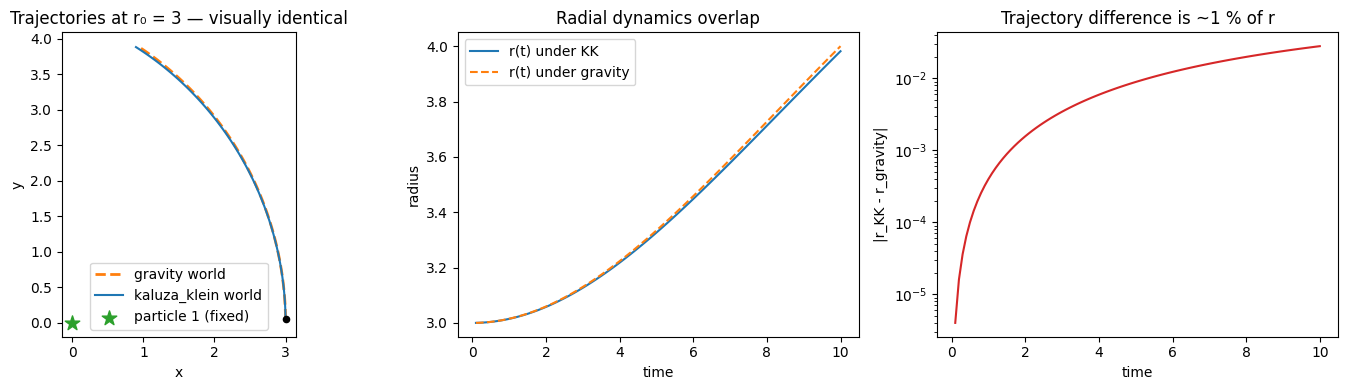

Max trajectory deviation over 10s: 0.0281  (radius ≈ 3.39)
Relative deviation                            : 0.83 %


In [4]:
gravity_world = get_world("gravity", engine="nbody")
gravity_executor = gravity_world["executor"]

case_default = {
    "p1": 1.0, "p2": 1.0,
    "pos2": [3.0, 0.0], "velocity2": [0.0, 0.5],
    "measurement_times": list(np.linspace(0.1, 10.0, 100)),
}

kk_res    = executor.run([case_default])[0]
grav_res  = gravity_executor.run([case_default])[0]

kk_pos    = np.array(kk_res["pos2"])
grav_pos  = np.array(grav_res["pos2"])
times     = np.array(case_default["measurement_times"])
sep_diff  = np.linalg.norm(kk_pos - grav_pos, axis=1)
kk_radius = np.linalg.norm(kk_pos,   axis=1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(grav_pos[:, 0], grav_pos[:, 1], "--", color="C1",
             lw=2.0, label="gravity world")
axes[0].plot(kk_pos[:, 0],   kk_pos[:, 1], color="C0",
             lw=1.5, label="extra_dimensions world")
axes[0].scatter(0, 0, color="C2", marker="*", s=120, zorder=4,
                label="particle 1 (fixed)")
axes[0].scatter(*grav_pos[0], color="k", s=20, zorder=4)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("Trajectories at r₀ = 3 — visually identical")
axes[0].legend()
axes[0].set_aspect("equal")

axes[1].plot(times, kk_radius, color="C0", label="r(t) under KK")
axes[1].plot(times, np.linalg.norm(grav_pos, axis=1), "--",
             color="C1", label="r(t) under gravity")
axes[1].set_xlabel("time"); axes[1].set_ylabel("radius")
axes[1].set_title("Radial dynamics overlap")
axes[1].legend()

axes[2].semilogy(times, np.maximum(sep_diff, 1e-12), color="C3")
axes[2].set_xlabel("time"); axes[2].set_ylabel("|r_KK - r_gravity|")
axes[2].set_title("Trajectory difference is ~1 % of r")

plt.tight_layout()
plt.show()

print(f"Max trajectory deviation over {times[-1]:.0f}s: "
      f"{sep_diff.max():.4f}  (radius ≈ {kk_radius.mean():.2f})")
print(f"Relative deviation                            : "
      f"{sep_diff.max() / kk_radius.mean() * 100:.2f} %")

## 3. Probing close: the extra dimension shows up

Now the *clever* experiment. Place particle 2 at $r_0 = 0.3$ — well inside the compactification radius $R_c = 0.5$ — and compare the trajectory under the KK world to the trajectory the same initial conditions would produce under (a) pure 2D gravity (the agent's "lazy" hypothesis) and (b) pure 3D Newtonian gravity with strength $G_{\rm 3D} = G L / (4\pi)$ (the asymptotic short-range form).

The trajectories are now **dramatically different**: the KK probe falls into the source ~3× faster than 2D gravity predicts, and tracks the 3D-Newton prediction almost perfectly. This is the signature an agent would search for.

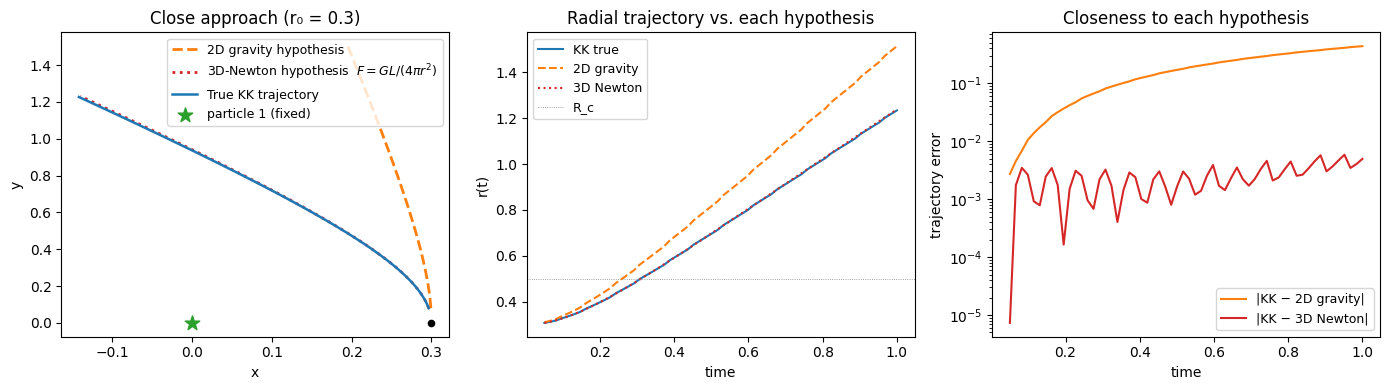

In [5]:
from scipy.integrate import solve_ivp


def integrate_central(F_of_r, pos0, vel0, t_eval, soft=0.05):
    """Integrate dq2/dt² = -F(r) r̂ using scipy. Returns positions at t_eval."""
    def rhs(t, y):
        x, yc, vx, vy = y
        r2 = x * x + yc * yc
        r = np.sqrt(r2)
        r_safe = np.sqrt(r2 + soft * soft)
        F = F_of_r(r_safe)
        ax = -F * x / max(r, 1e-12)
        ay = -F * yc / max(r, 1e-12)
        return [vx, vy, ax, ay]

    y0 = [pos0[0], pos0[1], vel0[0], vel0[1]]
    sol = solve_ivp(rhs, (t_eval[0], t_eval[-1]), y0,
                    t_eval=t_eval, method="RK45",
                    rtol=1e-9, atol=1e-11)
    return sol.y[:2].T


# Place particle 2 well inside R_c, and give it just enough tangential
# velocity to avoid spiralling all the way to the singular origin within
# the simulation window.
r0 = 0.3
case_close = {
    "p1": 1.0, "p2": 1.0,
    "pos2": [r0, 0.0], "velocity2": [0.0, 1.6],
    "measurement_times": list(np.linspace(0.05, 1.0, 60)),
}
times_close = np.array(case_close["measurement_times"])
times_full  = np.concatenate(([0.0], times_close))

kk_close   = np.array(executor.run([case_close])[0]["pos2"])
grav_close = np.array(gravity_executor.run([case_close])[0]["pos2"])

# Theoretical 3D-Newton prediction at the same IC: F = G L / (4π r²).
F_3d_predict = lambda r: G * L / (4 * np.pi * r**2)
y0 = [r0, 0.0, 0.0, 1.6]
pos3d = integrate_central(F_3d_predict,
                          y0[:2], y0[2:], times_full)[1:]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(grav_close[:, 0], grav_close[:, 1], "--", color="C1",
             lw=2.0, label="2D gravity hypothesis")
axes[0].plot(pos3d[:, 0],     pos3d[:, 1], ":", color="C3",
             lw=2.0, label=r"3D-Newton hypothesis  $F=GL/(4\pi r^2)$")
axes[0].plot(kk_close[:, 0],  kk_close[:, 1], color="C0",
             lw=1.8, label="True KK trajectory")
axes[0].scatter(0, 0, color="C2", marker="*", s=120, zorder=4,
                label="particle 1 (fixed)")
axes[0].scatter(r0, 0, color="k", s=20, zorder=4)
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title(f"Close approach (r₀ = {r0})")
axes[0].legend(loc="upper right", fontsize=9)
# axes[0].set_aspect("equal")

# Radial vs time
axes[1].plot(times_close, np.linalg.norm(kk_close, axis=1), color="C0",
             label="KK true")
axes[1].plot(times_close, np.linalg.norm(grav_close, axis=1), "--",
             color="C1", label="2D gravity")
axes[1].plot(times_close, np.linalg.norm(pos3d, axis=1), ":",
             color="C3", label="3D Newton")
axes[1].axhline(R, color="grey", lw=0.6, ls=":", label="R_c")
axes[1].set_xlabel("time"); axes[1].set_ylabel("r(t)")
axes[1].set_title("Radial trajectory vs. each hypothesis")
axes[1].legend(fontsize=9)

# Errors
axes[2].semilogy(times_close, np.linalg.norm(kk_close - grav_close, axis=1),
                 color="C1", label="|KK − 2D gravity|")
axes[2].semilogy(times_close, np.linalg.norm(kk_close - pos3d, axis=1),
                 color="C3", label="|KK − 3D Newton|")
axes[2].set_xlabel("time"); axes[2].set_ylabel("trajectory error")
axes[2].set_title("Closeness to each hypothesis")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

A clean way to map out $F(r)$ from short experiments is to start particle 2 at rest at distance $r_0$ and measure the radial velocity gained over a tiny interval $\Delta t$:

\[
\Delta v_r(r_0) \;\approx\; -F(r_0)\,\Delta t / p_2
\]

We sweep $r_0$ from below $R_c$ to well above $L$ and recover $F(r)$ across the entire crossover. The recovered curve should match the analytic image-sum to high precision and let us *fit* both $G$ and $R_c$.

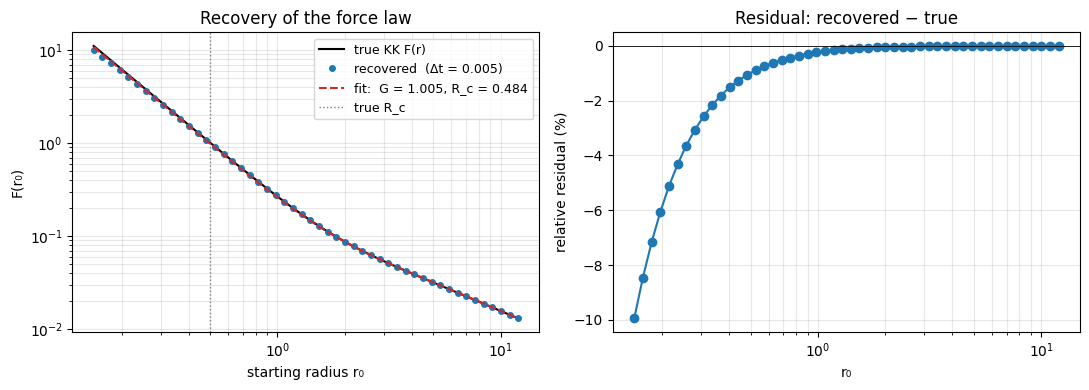

True   :  G = 1.000    R_c = 0.500
Fit    :  G = 1.005    R_c = 0.484
Errors :  ΔG/G = +0.45 %    ΔR/R = -3.22 %


In [7]:
delta_t = 0.005
r0_grid = np.geomspace(0.15, 12.0, 50)

exps = [
    {"p1": 1.0, "p2": 1.0,
     "pos2": [float(r0), 0.0], "velocity2": [0.0, 0.0],
     "measurement_times": [delta_t]}
    for r0 in r0_grid
]
strobe_results = executor.run(exps)
v_x_after = np.array([r["velocity2"][0][0] for r in strobe_results])
F_recovered = -v_x_after / delta_t              # p2 = 1, so F ≈ -Δv/Δt
F_true      = NBodyKaluzaKleinExecutor.force_magnitude(r0_grid)

# Fit (G, R_c) to the recovered force curve.  F(r) spans three orders of
# magnitude across the sweep, so we fit in log-F space to give large-r and
# small-r samples comparable weight (a linear-residual fit collapses to
# the small-r regime and barely constrains G).
from scipy.optimize import curve_fit


def kk_force_np(r, G_fit, R_fit, n_images=20):
    L_fit = 2 * np.pi * R_fit
    n_arr = np.arange(-n_images, n_images + 1, dtype=np.float64)
    y_n = n_arr * L_fit
    r_arr = np.asarray(r, dtype=np.float64)
    denom = (r_arr[..., None] ** 2 + y_n**2) ** 1.5
    F_geom = np.sum(r_arr[..., None] / denom, axis=-1)
    return G_fit * L_fit * F_geom / (4.0 * np.pi)


def log_kk_force_np(r, G_fit, R_fit):
    return np.log(kk_force_np(r, G_fit, R_fit))


popt, _ = curve_fit(log_kk_force_np, r0_grid, np.log(F_recovered),
                    p0=[1.0, 1.0], bounds=([1e-3, 1e-3], [10.0, 10.0]))
G_fit, R_fit = popt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].loglog(r0_grid, F_true, color="k", lw=1.5, label="true KK F(r)")
axes[0].loglog(r0_grid, F_recovered, "o", ms=4, color="C0",
               label=f"recovered  (Δt = {delta_t})")
axes[0].loglog(r0_grid, kk_force_np(r0_grid, G_fit, R_fit), "--",
               color="C3",
               label=f"fit:  G = {G_fit:.3f}, R_c = {R_fit:.3f}")
axes[0].axvline(R, color="grey", ls=":", lw=1.0, label="true R_c")
axes[0].set_xlabel("starting radius r₀"); axes[0].set_ylabel("F(r₀)")
axes[0].set_title("Recovery of the force law")
axes[0].legend(fontsize=9)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogx(r0_grid, (F_recovered - F_true) / F_true * 100, "o-",
                 color="C0")
axes[1].axhline(0, color="k", lw=0.6)
axes[1].set_xlabel("r₀"); axes[1].set_ylabel("relative residual (%)")
axes[1].set_title("Residual: recovered − true")
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"True   :  G = {G:.3f}    R_c = {R:.3f}")
print(f"Fit    :  G = {G_fit:.3f}    R_c = {R_fit:.3f}")
print(f"Errors :  ΔG/G = {(G_fit - G)/G * 100:+.2f} %    "
      f"ΔR/R = {(R_fit - R)/R * 100:+.2f} %")

## 5. Reference `discovered_law` — what a successful agent should converge to

Below is the law a 10/10 agent would submit. It integrates the KK image-sum force with `scipy.solve_ivp` and exposes $G$ and $R_c$ as fittable parameters via `fit_parameters()`. We then run it through the standard 2-particle `Evaluator` to confirm it matches the executor's ground-truth trajectories with essentially zero error — a sanity check that (a) the rubric's 10/10 answer is achievable and (b) the world is internally consistent with the evaluator and the MSE-fit pipeline.

In [8]:
REFERENCE_LAW_SOURCE = '''
def discovered_law(pos1, pos2, p1, p2, velocity2, duration, **params):
    """Kaluza-Klein extra-dimension force: visible 2D world with one
    spatial dimension compactified at radius R_c.  Image-charge sum:

        F(r) = (G L p1 / (4π)) * Σ_n  r/(r² + (n L)²)^(3/2)

    with L = 2π R_c.  Two limits: 2D Poisson (1/r) at r >> R_c,
    3D Newtonian (1/r²) at r << R_c.
    """
    import numpy as np
    from scipy.integrate import solve_ivp

    G   = params.get("G",         1.0)
    R_c = params.get("R_compact", 1.0)
    n_images = 20
    soft = 0.05

    L = 2.0 * np.pi * R_c
    n_arr = np.arange(-n_images, n_images + 1, dtype=np.float64)
    y_n2 = (n_arr * L) ** 2
    pref = G * L / (4.0 * np.pi)

    def F_of_r(r):
        denom = (r * r + y_n2) ** 1.5
        return pref * np.sum(r / denom)

    def rhs(t, y):
        x, yc, vx, vy = y
        r2 = x * x + yc * yc
        r  = np.sqrt(r2)
        r_safe = np.sqrt(r2 + soft * soft)
        F = F_of_r(r_safe) * p1
        if r < 1e-12:
            return [vx, vy, 0.0, 0.0]
        coeff = -F / (p2 * r)
        return [vx, vy, coeff * x, coeff * yc]

    y0 = [pos2[0], pos2[1], velocity2[0], velocity2[1]]
    sol = solve_ivp(rhs, (0.0, float(duration)), y0,
                    method="RK45", rtol=1e-8, atol=1e-10)
    yT = sol.y[:, -1]
    return [yT[0], yT[1]], [yT[2], yT[3]]


def fit_parameters():
    # Initial guess of R_compact = 1.0 sits between the two regimes so the
    # optimiser can move in either direction; bounds are deliberately wide
    # because the agent has no prior on the compactification scale.
    return {
        "G":         {"init": 1.0, "bounds": [0.05, 10.0]},
        "R_compact": {"init": 1.0, "bounds": [0.05, 10.0]},
    }
'''.strip()

ns = {}
exec(REFERENCE_LAW_SOURCE, ns)
reference_law = ns["discovered_law"]

# Sanity-check the law with the *true* hidden parameters: it should
# track the executor to integrator precision.
true_params = {"G": NBodyKaluzaKleinExecutor.G,
               "R_compact": NBodyKaluzaKleinExecutor.R_COMPACT}

cases = [
    {"p1": 1.0, "p2": 1.0,
     "pos2": [3.0, 0.0], "velocity2": [0.0, 0.5],
     "measurement_times": [1.0, 2.0, 3.0, 4.0, 5.0,
                           6.0, 7.0, 8.0, 9.0, 10.0]},
    {"p1": 1.0, "p2": 1.0,
     "pos2": [0.4, 0.0], "velocity2": [0.0, 1.5],
     "measurement_times": [0.1, 0.2, 0.3, 0.4, 0.5,
                           0.6, 0.7, 0.8, 0.9, 1.0]},
    {"p1": 2.0, "p2": 0.5,
     "pos2": [6.0, 0.0], "velocity2": [0.0, 0.3],
     "measurement_times": [0.5, 1.0, 1.5, 2.0, 2.5,
                           3.0, 3.5, 4.0, 4.5, 5.0]},
]

print("Sanity check: ground-truth-parameters reference law vs executor")
print("-" * 70)
for k, case in enumerate(cases):
    gt = executor.run([case])[0]
    gt_pos2 = np.array(gt["pos2"])
    pred = []
    for t, gt_p in zip(case["measurement_times"], gt_pos2):
        p2_pred, _ = reference_law(
            pos1=[0.0, 0.0],
            pos2=case["pos2"],
            p1=case["p1"],
            p2=case["p2"],
            velocity2=case["velocity2"],
            duration=t,
            **true_params,
        )
        pred.append(p2_pred)
    pred = np.array(pred)
    err = np.linalg.norm(pred - gt_pos2, axis=1)
    print(f"  case {k}: r₀={np.linalg.norm(case['pos2']):.2f}, "
          f"max |err| = {err.max():.2e}, "
          f"mean |err| = {err.mean():.2e}")

Sanity check: ground-truth-parameters reference law vs executor
----------------------------------------------------------------------
  case 0: r₀=3.00, max |err| = 8.83e-09, mean |err| = 3.11e-09
  case 1: r₀=0.40, max |err| = 1.61e-09, mean |err| = 7.90e-10
  case 2: r₀=6.00, max |err| = 8.54e-09, mean |err| = 2.99e-09


### 5b. End-to-end Evaluator with `fit_parameters()`

Finally, run the full pipeline the same way the agent's submission would be scored: a tiny "training" set of trajectories at *both* short and long range, scipy fits $G$ and $R_c$ from this small sample, and then the fitted law is evaluated against a held-out batch. We expect both fit parameters to land within ~5 % of truth and the test-set MSE to be small.

In [7]:
from scienceagent.evaluator import _compile_law, _maybe_fit, _two_particle_loss

# Build a small training set that *spans both regimes* — short approach
# at r₀ ≈ 0.3 plus a long-range orbit at r₀ ≈ 6.0.  This is exactly the
# kind of multi-scale campaign a successful agent would design.
train_cases = [
    {"p1": 1.0, "p2": 1.0,
     "pos2": [0.3, 0.0], "velocity2": [0.0, 1.6],
     "measurement_times": [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]},
    {"p1": 1.0, "p2": 1.0,
     "pos2": [6.0, 0.0], "velocity2": [0.0, 0.3],
     "measurement_times": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]},
]

# The evaluator's _maybe_fit pipeline expects samples shaped as
# {"input": case, "output": executor_result}.
train_trajectories = []
for case in train_cases:
    res = executor.run([case])[0]
    train_trajectories.append({"input": case, "output": res})

# fit_parameters() optimisation pipeline (same code path the evaluator uses).
init_law = _compile_law(REFERENCE_LAW_SOURCE)
fitted_law, fit_info = _maybe_fit(
    REFERENCE_LAW_SOURCE,
    init_law,
    train_trajectories,
    _two_particle_loss,
    verbose=True,
)

print("Fit info:", fit_info)
print()

# Evaluate the fitted law on a held-out test set spanning the same regimes.
test_cases = [
    {"p1": 1.0, "p2": 1.0,
     "pos2": [0.4, 0.0], "velocity2": [0.0, 1.4],
     "measurement_times": [0.1, 0.3, 0.5, 0.8, 1.0]},
    {"p1": 1.0, "p2": 1.0,
     "pos2": [4.0, 0.0], "velocity2": [0.0, 0.4],
     "measurement_times": [1.0, 2.0, 4.0, 6.0, 8.0]},
]

print("Held-out test cases:")
print("-" * 70)
total_mse = 0.0; n_pts = 0
for k, case in enumerate(test_cases):
    gt = executor.run([case])[0]
    gt_pos2 = np.array(gt["pos2"])
    pred = []
    for t in case["measurement_times"]:
        p2_pred, _ = fitted_law(
            pos1=[0.0, 0.0],
            pos2=case["pos2"],
            p1=case["p1"],
            p2=case["p2"],
            velocity2=case["velocity2"],
            duration=t,
        )
        pred.append(p2_pred)
    pred = np.array(pred)
    sq = ((pred - gt_pos2) ** 2).sum(axis=1)
    total_mse += sq.sum(); n_pts += len(sq)
    print(f"  case {k}: r₀={np.linalg.norm(case['pos2']):.2f}, "
          f"RMS error = {np.sqrt(sq.mean()):.4f}")

print()
print(f"Aggregate MSE over held-out test set: {total_mse / n_pts:.6e}")

  Fitted parameters: G=1, R_compact=0.5
  Training-set loss: 0.07595 → 8.618e-11
Fit info: {'declared_params': {'G': {'init': 1.0, 'bounds': [0.05, 10.0]}, 'R_compact': {'init': 1.0, 'bounds': [0.05, 10.0]}}, 'fitted_params': {'G': 1.0000172724452625, 'R_compact': 0.5000003965685834}, 'loss_before': 0.07594549945687314, 'loss_after': 8.617866403169112e-11, 'error': None}

Held-out test cases:
----------------------------------------------------------------------
  case 0: r₀=0.40, RMS error = 0.0000


  case 1: r₀=4.00, RMS error = 0.0000

Aggregate MSE over held-out test set: 8.266561e-11
